#EMBEDDING WITH SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

In [1]:
#!pip install ipywidgets --q


In [2]:
# !pip install sentence-transformers xgboost scikit-learn pandas optuna tensorboard joblib --q

In [1]:
import os, joblib, pandas as pd, numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from datetime import datetime

e:\KLTN\Data_mining\env1\Lib\site-packages\transformers\utils\hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
df = pd.read_csv("datas/combined.csv").dropna(subset=["combined_text","story_point"])
texts = df["combined_text"].tolist()
y = df["story_point"].values

In [3]:
len(texts), len(y)

(93056, 93056)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93056 entries, 0 to 93055
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   key            93056 non-null  object 
 1   story_point    93056 non-null  float64
 2   title          93056 non-null  object 
 3   description    90223 non-null  object 
 4   combined_text  93056 non-null  object 
dtypes: float64(1), object(4)
memory usage: 3.5+ MB


In [5]:
df["story_point"]

0         2.0
1         5.0
2        20.0
3         5.0
4        13.0
         ... 
93051     1.0
93052     2.0
93053     3.0
93054     2.0
93055     2.0
Name: story_point, Length: 93056, dtype: float64

In [6]:
df.duplicated().sum()

np.int64(1586)

In [7]:
# Xóa các dữ liệu issue trùng lặp
df = df.drop_duplicates().copy()
# Update texts and y to reflect the cleaned DataFrame
texts_cleaned = df["combined_text"].tolist()
y_cleaned = df["story_point"].values

print(f"Texts: {len(texts)}  --> {len(texts_cleaned)}")
print(f"Y: {len(y)}  --> {len(y_cleaned)}")

# Sử dụng texts_cleaned và y_cleaned cho các bước tiếp theo

Texts: 93056  --> 91470
Y: 93056  --> 91470


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# Kiểm tra giá trị null -- Description bị null không sao, 
#       Phần train sẽ chỉ lấy mỗi combined_text (title + desc) 
#       hoặc có thể bỏ các dòng dữ liệu đó luôn
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
key                 0
story_point         0
title               0
description      2778
combined_text       0
dtype: int64


In [9]:
print(df.describe(include='all'))

           key  story_point         title description combined_text
count    91470  91470.00000         91470       88692         91470
unique      28          NaN         38784       42975         87857
top     TISTUD          NaN  lint failure      #NAME?  Provisioning
freq     27999          NaN            16          61             4
mean       NaN      4.63751           NaN         NaN           NaN
std        NaN      7.77140           NaN         NaN           NaN
min        NaN      0.00000           NaN         NaN           NaN
25%        NaN      1.00000           NaN         NaN           NaN
50%        NaN      3.00000           NaN         NaN           NaN
75%        NaN      5.00000           NaN         NaN           NaN
max        NaN    100.00000           NaN         NaN           NaN


In [13]:
!pip install -U matplotlib seaborn -q


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


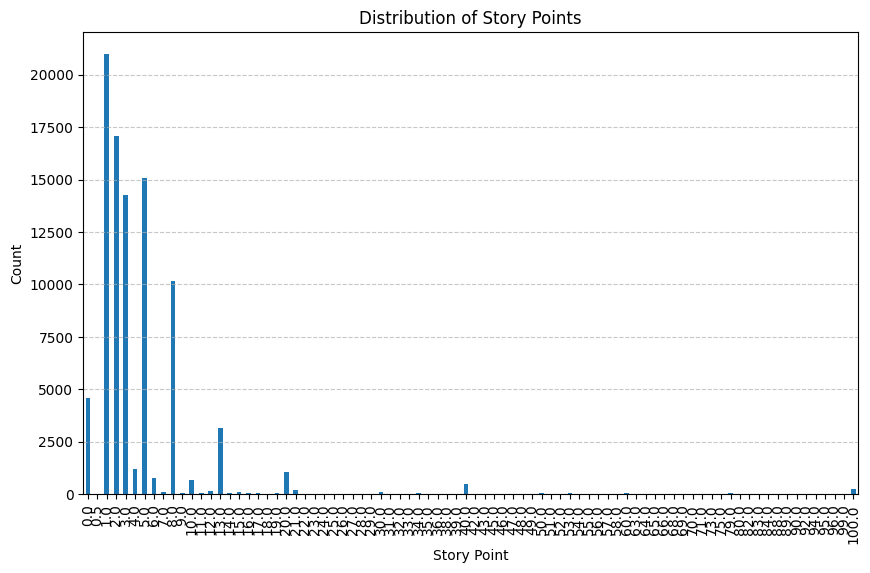

In [10]:
# Phân bố story point
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df['story_point'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Story Points')
plt.xlabel('Story Point')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

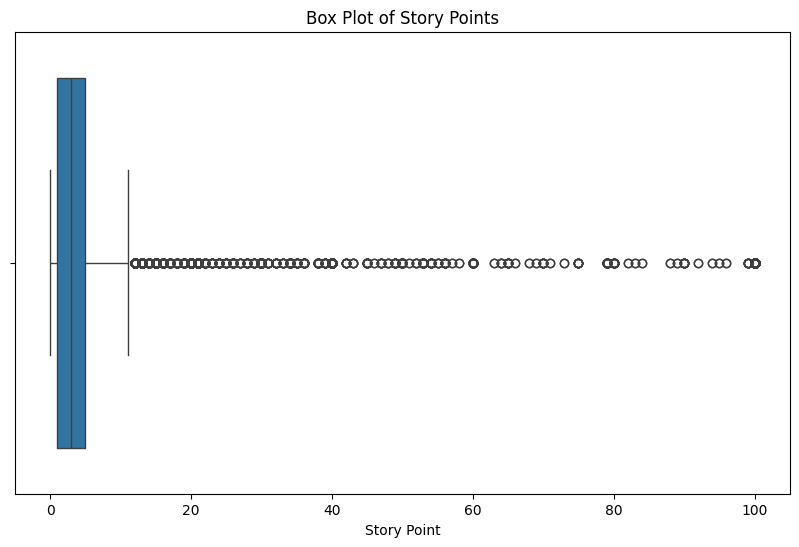

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['story_point'])
plt.title('Box Plot of Story Points')
plt.xlabel('Story Point')
plt.show()

In [12]:
#Xử lý giá trị ngoại lai
Q1 = df['story_point'].quantile(0.25)
Q3 = df['story_point'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df_filtered = df[(df['story_point'] >= lower_bound) & (df['story_point'] <= upper_bound)].copy()

# Update texts and y to reflect the filtered DataFrame
texts_filtered = df_filtered["combined_text"].tolist()
y_filtered = df_filtered["story_point"].values

print(f"Data shape: {df.shape} --> {df_filtered.shape}")

# LƯU Ý LÀ SỬ DỤNG: df_filtered, texts_filtered, and y_filtered cho các bước sau

Data shape: (91470, 5) --> (85044, 5)


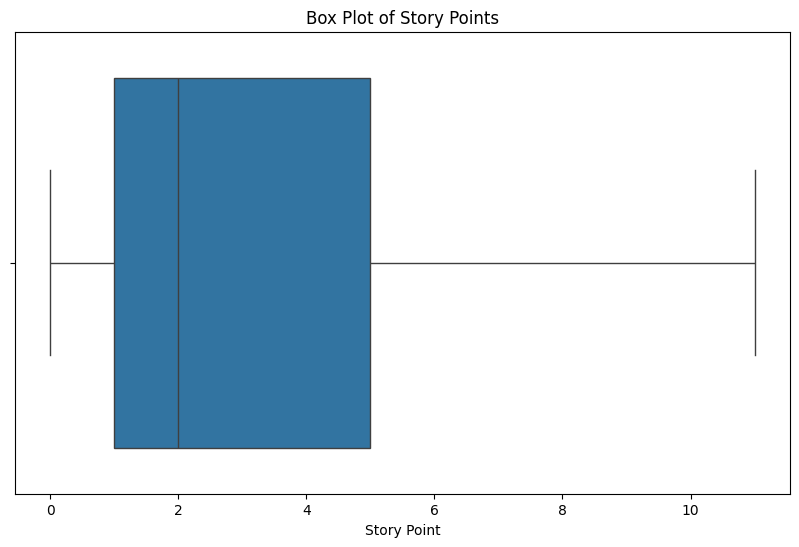

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df_filtered['story_point'])
plt.title('Box Plot of Story Points')
plt.xlabel('Story Point')
plt.show()

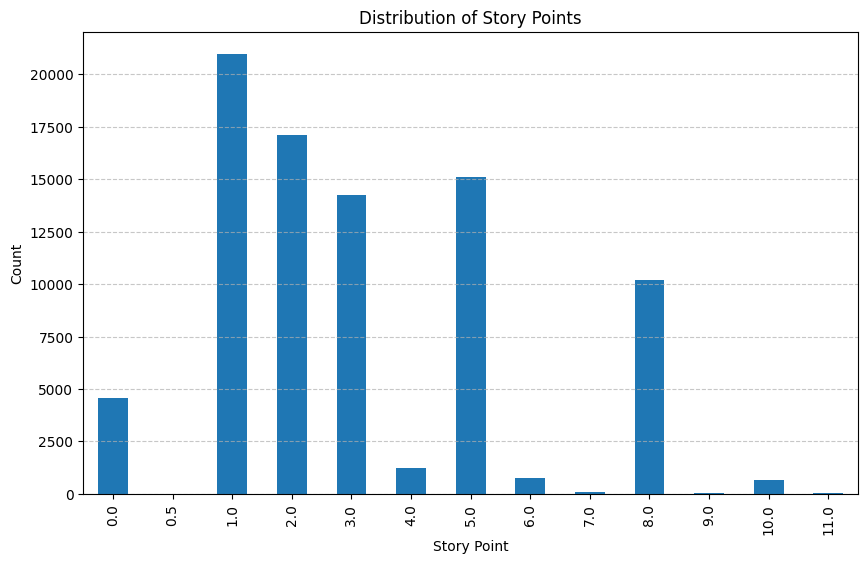

In [14]:
# Phân bố story point
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df_filtered['story_point'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Story Points')
plt.xlabel('Story Point')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [15]:
df_filtered.shape

(85044, 5)

In [16]:
df_filtered.head()

,key,story_point,title,description,combined_text
0,JSW,2.0,"Add text to the Agile Gadget ""Invalid Project""...","When the error is ""Invalid Project"" add detail...","Add text to the Agile Gadget ""Invalid Project""..."
1,JSW,5.0,Generic webwork aliases may clash with other p...,Some web work actions have commands that have ...,Generic webwork aliases may clash with other p...
3,JSW,5.0,Version can be set in the create issue screen ...,Costumer has a project in which some users don...,Version can be set in the create issue screen ...
6,JSW,3.0,GreenHopper appends Project IDs to URL when ad...,Per ticket here: https://support.atlassian.com...,GreenHopper appends Project IDs to URL when ad...
7,JSW,2.0,Investigate: Log work operation of a task in t...,*Steps to reproduce:* 1. Click on Agile Tab 2....,Investigate: Log work operation of a task in t...


In [17]:
texts_filtered[1]

'Generic webwork aliases may clash with other plugins. Some web work actions have commands that have very generic aliases, such as "Update", "Move" and "Synch" etc. These aliases have a good chance to clash with the action name or aliases used by other plugins. These aliases should be given a name specific to the plugin, such as "UpdateGreenHopperDropBoard"... Alternatively, the bang syntax can be used in place of command aliases, such as "DropBoardAction!update". In this case, there is no need to define aliases for commands. (However, still need to define alias as an empty String; otherwise, a NPE will be thrown when parsing the xml.)'

In [22]:
# !pip install -q -U sentence-transformers tqdm --quiet

In [18]:
# Chuẩn hóa Mã dự án (Key)
from sklearn.preprocessing import LabelEncoder

# Encode key
le = LabelEncoder()
df_filtered["key_encoder"] = le.fit_transform(df_filtered["key"].astype(str))



In [19]:
df_filtered["key_encoder"].unique() # Các mã key của dự án được mã hóa thành các số

array([14, 16, 15, 18, 22, 23, 26,  2,  4, 25,  0,  1,  3,  5,  6,  7,  8,
        9, 10, 11, 12, 13, 17, 19, 20, 21, 24, 27])

In [20]:
# Thêm các đặc trưng về độ dài văn bản
df_filtered["word_count"] = df_filtered["combined_text"].apply(lambda x: len(x.split()))
df_filtered["char_count"] = df_filtered["combined_text"].apply(lambda x: len(x))
# Chuẩn hóa các đặc trưng độ dài
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_filtered[["word_norm", "char_norm"]] = scaler.fit_transform(df_filtered[["word_count", "char_count"]])

In [21]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85044 entries, 0 to 93055
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   key            85044 non-null  object 
 1   story_point    85044 non-null  float64
 2   title          85044 non-null  object 
 3   description    82627 non-null  object 
 4   combined_text  85044 non-null  object 
 5   key_encoder    85044 non-null  int64  
 6   word_count     85044 non-null  int64  
 7   char_count     85044 non-null  int64  
 8   word_norm      85044 non-null  float64
 9   char_norm      85044 non-null  float64
dtypes: float64(3), int64(3), object(4)
memory usage: 7.1+ MB


In [22]:
df_filtered.head()

,key,story_point,title,description,combined_text,key_encoder,word_count,char_count,word_norm,char_norm
0,JSW,2.0,"Add text to the Agile Gadget ""Invalid Project""...","When the error is ""Invalid Project"" add detail...","Add text to the Agile Gadget ""Invalid Project""...",14,37,364,0.000879,0.000258
1,JSW,5.0,Generic webwork aliases may clash with other p...,Some web work actions have commands that have ...,Generic webwork aliases may clash with other p...,14,105,642,0.002539,0.000458
3,JSW,5.0,Version can be set in the create issue screen ...,Costumer has a project in which some users don...,Version can be set in the create issue screen ...,14,110,645,0.002661,0.000460
6,JSW,3.0,GreenHopper appends Project IDs to URL when ad...,Per ticket here: https://support.atlassian.com...,GreenHopper appends Project IDs to URL when ad...,14,103,753,0.002490,0.000537
7,JSW,2.0,Investigate: Log work operation of a task in t...,*Steps to reproduce:* 1. Click on Agile Tab 2....,Investigate: Log work operation of a task in t...,14,83,481,0.002002,0.000342


In [28]:
from sentence_transformers import SentenceTransformer
import numpy as np
import json, os
from tqdm.notebook import tqdm
import time

# chọn model

MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embed_model = SentenceTransformer(MODEL_NAME, device="cuda")

def get_embedding(text):
    # if text in emb_cache:
    #     return emb_cache[text]

    emb = embed_model.encode(text, normalize_embeddings=True).tolist()
    # emb_cache[text] = emb
    return emb


# Embed toàn bộ data
embeddings_list = []
texts = df_filtered["combined_text"].tolist()

start_time = time.perf_counter()

for text in tqdm(texts, desc="Embedding texts..."):
    emb = get_embedding(text)
    embeddings_list.append(emb)
    
end_time = time.perf_counter()
# Lưu cache
# with open(CACHE_FILE, "w", encoding="utf-8") as f:
#     json.dump(emb_cache, f, ensure_ascii=False)

X_emb = np.array(embeddings_list)
print("✅ Done! Shape:", X_emb.shape)
print(f"Time taken for embedding: {end_time - start_time:.2f} seconds")


Embedding texts...:   0%|          | 0/85044 [00:00<?, ?it/s]

✅ Done! Shape: (85044, 384)
Time taken for embedding: 995.79 seconds


In [47]:
np.save("embedX/[MiniL12]X_embed.npy", X_emb)
print("Saved embeddings to [MiniL12]X_embed.npy.npy")

Saved embeddings to [MiniL12]X_embed.npy.npy


In [23]:
test_emb = np.load("embedX/[MiniL12]X_embed.npy")
test_emb.shape

(85044, 384)

In [24]:
# Đây là phần sử dụng lại embeddings đã lưu
X = test_emb

In [ ]:
# KHÔNG chạy đoạn này nếu đã lưu embeddings
embeddings_list[1]

In [ ]:
# KHÔNG chạy đoạn này nếu đã lưu embeddings
# Kết hợp embedding với các đặc trưng độ dài
extra = df_filtered[["word_norm", "char_norm", "key_encoder"]].values
X = np.hstack([X_emb, extra])

In [ ]:
# KHÔNG chạy đoạn này nếu đã lưu embeddings
print("X_emb shape:", X_emb.shape)
print("extra shape:", extra.shape)
print("Final X shape:", X.shape)

X_emb shape: (85044, 384)
extra shape: (85044, 3)
Final X shape: (85044, 387)


In [25]:
extra = df_filtered[["word_norm", "char_norm", "key_encoder"]].values
X = np.hstack([X, extra])

In [26]:
X.shape, y_filtered.shape

((85044, 387), (85044,))

In [27]:
X[1]

array([-9.00898799e-02, -3.99700627e-02, -3.96355279e-02, -3.79686104e-03,
        4.27054651e-02,  4.67559546e-02,  5.22425957e-02, -8.20364505e-02,
       -3.87818756e-04,  3.50464322e-02,  3.83779057e-03,  1.49245383e-02,
        1.85291842e-02, -3.15880850e-02,  1.25082061e-01,  2.58075772e-03,
        9.05860960e-03,  1.66629720e-02,  1.15134511e-02,  1.94589496e-02,
       -7.81030655e-02,  3.87507258e-04,  1.60253681e-02,  5.87374419e-02,
       -8.40728581e-02, -1.15186116e-02, -2.38862541e-02, -2.27326900e-03,
       -2.78401896e-02, -6.67456836e-02,  6.74642399e-02,  4.58948947e-02,
       -1.65054016e-02, -7.42968731e-03, -6.54427633e-02, -5.80961350e-03,
       -6.96817711e-02, -1.40203554e-02, -8.37877840e-02, -6.98429644e-02,
       -2.52036075e-03, -3.13056968e-02, -4.89639901e-02, -6.61616400e-02,
       -4.07092050e-02, -1.02629168e-02,  2.30692141e-02, -8.73914827e-03,
       -5.85359372e-02, -6.14651106e-03, -3.10674943e-02, -7.69801736e-02,
        6.38662232e-03,  

In [28]:
y = df_filtered["story_point"].values
y.shape

(85044,)

In [29]:
import numpy as np

X = np.array(X, dtype=float)
y = np.array(y, dtype=float)

print(" Converted to numpy arrays")
print("X shape:", X.shape)
print("y shape:", y.shape)

 Converted to numpy arrays
X shape: (85044, 387)
y shape: (85044,)


In [30]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)



Shape of X_train: (68035, 387)
Shape of X_test: (17009, 387)
Shape of y_train: (68035,)
Shape of y_test: (17009,)


In [31]:
X_train[1]

array([ 1.58941792e-03,  5.87490294e-03,  3.98241132e-02, -4.14217077e-02,
        4.60716523e-02, -5.33310045e-03, -2.12505609e-02,  5.65870153e-03,
        6.07175846e-03, -2.89185671e-03, -4.24994975e-02,  2.66575254e-02,
       -4.56793718e-02, -3.53735499e-02, -2.33971234e-02, -2.48209629e-02,
       -6.84233941e-03, -5.09159593e-03, -2.39205881e-04, -1.41763547e-02,
       -6.04666285e-02, -4.41418849e-02,  4.02032472e-02,  4.23731777e-04,
       -5.21956719e-02,  1.01173483e-01, -4.98531982e-02,  6.08527362e-02,
        1.18069343e-01, -4.09998782e-02,  3.52376066e-02,  9.54657570e-02,
       -6.03926964e-02, -2.69552059e-02,  1.68653224e-02,  5.05250022e-02,
        1.94484834e-02, -6.59888163e-02, -1.30006492e-01, -6.98113739e-02,
        2.37283334e-02, -7.92896599e-02,  9.25998092e-02,  2.84451842e-02,
       -8.15614536e-02, -1.42102903e-02, -2.93409303e-02,  4.22251225e-03,
       -6.99610114e-02, -4.92911190e-02, -1.23735778e-01, -7.48111978e-02,
        6.26101568e-02, -

In [37]:
# !pip install lazypredict --quiet
# !pip install ipywidgets --upgrade
# !pip install --upgrade ipywidgets jupyter
# !pip install --upgrade xgboost --quiet

HÀM ĐÁNH GIÁ MODEL

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_regression(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }


In [40]:
# Tập lưu kết quả
results = []

TRAIN LightGBM

In [39]:
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation

                
lgb_model = lgb.LGBMRegressor(
    objective="regression",
    boosting_type="gbdt",
    max_depth=6,
    num_leaves=31,       
    learning_rate=0.01,
    n_estimators=10000,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=2,
    random_state=42
)


lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=500)  # log mỗi 500 rounds
    ]
)
# 3m7.7s

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.066849 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 98458
[LightGBM] [Info] Number of data points in the train set: 68035, number of used features: 387
[LightGBM] [Info] Start training from score 3.210921
Training until validation scores don't improve for 50 rounds
[500]	valid_0's rmse: 2.06775	valid_0's l2: 4.27558
[1000]	valid_0's rmse: 2.02574	valid_0's l2: 4.10364
[1500]	valid_0's rmse: 1.99659	valid_0's l2: 3.98636
[2000]	valid_0's rmse: 1.97351	valid_0's l2: 3.89473
[2500]	valid_0's rmse: 1.95425	valid_0's l2: 3.8191
[3000]	valid_0's rmse: 1.93713	valid_0's l2: 3.75248
[3500]	valid_0's rmse: 1.92097	valid_0's l2: 3.69012
[4000]	valid_0's rmse: 1.90665	valid_0's l2: 3.63531
[4500]	valid_0's rmse: 1.89308	valid_0's l2: 3.58376
[5000]	valid_0's rmse: 1.88064	valid_0's l2: 3.5368
[5500]	valid_0's rmse: 1.86958	valid_0's l2: 3.49534
[6000]	valid_0'

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.01
,n_estimators,10000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,2


In [42]:
# LightGBM
lgb_eval = evaluate_regression("LightGBM", y_test, lgb_model.predict(X_test))
print(lgb_eval)
results.append(lgb_eval)

e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'Model': 'LightGBM', '  MAE': 1.3509748667528223, '  MSE': 3.214692805243527, '  RMSE': np.float64(1.7929564426509437), '  R2': 0.4463870644994544}


TRAIN RANDOM FOREST

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
# Đánh giá trên tập test
rf_eval = evaluate_regression("RandomForest", y_test, rf_model.predict(X_test))
print(rf_eval)
results.append(rf_eval)

{'Model': 'RandomForest', '  MAE': 1.5596079561566347, '  MSE': 4.119212357132833, '  RMSE': np.float64(2.0295842818500622), '  R2': 0.2906167453192543}


Train Decision Tree

In [46]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42,
    min_samples_split=5,
)
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [48]:
# Đánh giá trên tập test
dt_eval = evaluate_regression("DecisionTree", y_test, dt_model.predict(X_test))
print(dt_eval)
results.append(dt_eval)

{'Model': 'DecisionTree', '  MAE': 1.6667934899603052, '  MSE': 5.00633099171262, '  RMSE': np.float64(2.237483182442411), '  R2': 0.13784309595970168}


Train XGBoostRegressor

In [49]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=10000,           # cho phép chạy max (model tự dừng trước)
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    min_child_weight=2,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    early_stopping_rounds=50,   # dừng nếu 50 rounds không cải thiện
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=500
)

[0]	validation_0-rmse:2.39538
[500]	validation_0-rmse:1.95375
[1000]	validation_0-rmse:1.87960
[1500]	validation_0-rmse:1.82498
[2000]	validation_0-rmse:1.78308
[2500]	validation_0-rmse:1.75051
[3000]	validation_0-rmse:1.72468
[3500]	validation_0-rmse:1.70468
[4000]	validation_0-rmse:1.68823
[4500]	validation_0-rmse:1.67422
[5000]	validation_0-rmse:1.66297
[5500]	validation_0-rmse:1.65331
[6000]	validation_0-rmse:1.64526
[6500]	validation_0-rmse:1.63866
[7000]	validation_0-rmse:1.63297
[7500]	validation_0-rmse:1.62835
[8000]	validation_0-rmse:1.62428
[8500]	validation_0-rmse:1.62091
[9000]	validation_0-rmse:1.61811
[9500]	validation_0-rmse:1.61565
[9999]	validation_0-rmse:1.61352


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'rmse'


In [51]:
# Đánh giá trên tập test
xgb_eval = evaluate_regression("XGBoost", y_test, xgb_model.predict(X_test))
print(xgb_eval)
results.append(xgb_eval)

{'Model': 'XGBoost', '  MAE': 1.1614894272919192, '  MSE': 2.603446325368032, '  RMSE': np.float64(1.613519855895189), '  R2': 0.551651852937805}


In [52]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=10000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=500
)

cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test)
)

0:	learn: 2.4206537	test: 2.3992264	best: 2.3992264 (0)	total: 201ms	remaining: 33m 29s
500:	learn: 2.0351891	test: 2.0842040	best: 2.0842040 (500)	total: 22.9s	remaining: 7m 13s
1000:	learn: 1.9157768	test: 2.0302554	best: 2.0302554 (1000)	total: 44.8s	remaining: 6m 42s
1500:	learn: 1.8207982	test: 1.9955505	best: 1.9955505 (1500)	total: 1m 6s	remaining: 6m 19s
2000:	learn: 1.7353684	test: 1.9667238	best: 1.9667238 (2000)	total: 1m 29s	remaining: 5m 58s
2500:	learn: 1.6594867	test: 1.9433827	best: 1.9433827 (2500)	total: 1m 50s	remaining: 5m 31s
3000:	learn: 1.5890011	test: 1.9233466	best: 1.9233466 (3000)	total: 2m 11s	remaining: 5m 6s
3500:	learn: 1.5244577	test: 1.9040017	best: 1.9040017 (3500)	total: 2m 32s	remaining: 4m 43s
4000:	learn: 1.4629712	test: 1.8865683	best: 1.8865683 (4000)	total: 2m 56s	remaining: 4m 24s
4500:	learn: 1.4063771	test: 1.8706180	best: 1.8706180 (4500)	total: 3m 22s	remaining: 4m 7s
5000:	learn: 1.3527295	test: 1.8559042	best: 1.8559042 (5000)	total: 3m 4

In [54]:
# Đánh giá trên tập test
cb_eval = evaluate_regression("CatBoost", y_test, cat_model.predict(X_test))
print(cb_eval)
results.append(cb_eval)

{'Model': 'CatBoost', '  MAE': 1.316744678421946, '  MSE': 3.077271833403984, '  RMSE': np.float64(1.7542154466894835), '  R2': 0.4700527869272195}


In [ ]:
results

[{'Model': 'LightGBM',
  'MAE': 1.3509748667528223,
  'MSE': 3.214692805243527,
  'RMSE': np.float64(1.7929564426509437),
  'R2': 0.4463870644994544},
 {'Model': 'RandomForest',
  'MAE': 1.5596079561566347,
  'MSE': 4.119212357132833,
  'RMSE': np.float64(2.0295842818500622),
  'R2': 0.2906167453192543},
 {'Model': 'DecisionTree',
  'MAE': 1.6667934899603052,
  'MSE': 5.00633099171262,
  'RMSE': np.float64(2.237483182442411),
  'R2': 0.13784309595970168},
 {'Model': 'XGBoost',
  'MAE': 1.1614894272919192,
  'MSE': 2.603446325368032,
  'RMSE': np.float64(1.613519855895189),
  'R2': 0.551651852937805},
 {'Model': 'CatBoost',
  'MAE': 1.316744678421946,
  'MSE': 3.077271833403984,
  'RMSE': np.float64(1.7542154466894835),
  'R2': 0.4700527869272195}]

Plot biểu đồ

In [58]:
import numpy as np
import matplotlib.pyplot as plt

In [79]:
import matplotlib.pyplot as plt

def plot_metric(results, metric_key, title, ylabel, ylim=None):
    """
    Plot bar chart và line chart cho 1 metric
    
    results   : list[dict]
    metric_key: key của metric (vd: 'RMSE', 'R2')
    title     : tiêu đề chung
    ylabel    : nhãn trục y
    ylim      : tuple (min, max) hoặc None
    """

    model_names = [res["Model"] for res in results]
    values = [res[metric_key] for res in results]

    # ===== Bar chart =====
    plt.figure(figsize=(10, 6))
    plt.bar(model_names, values, alpha=0.7)
    plt.title(f'{title} (Bar Chart)')
    plt.xlabel('Model')
    plt.ylabel(ylabel)
    if ylim:
        plt.ylim(*ylim)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # ===== Line chart =====
    plt.figure(figsize=(10, 6))
    plt.plot(model_names, values, marker='o', linewidth=2)
    plt.title(f'{title} (Line Chart)')
    plt.xlabel('Model')
    plt.ylabel(ylabel)
    if ylim:
        plt.ylim(*ylim)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


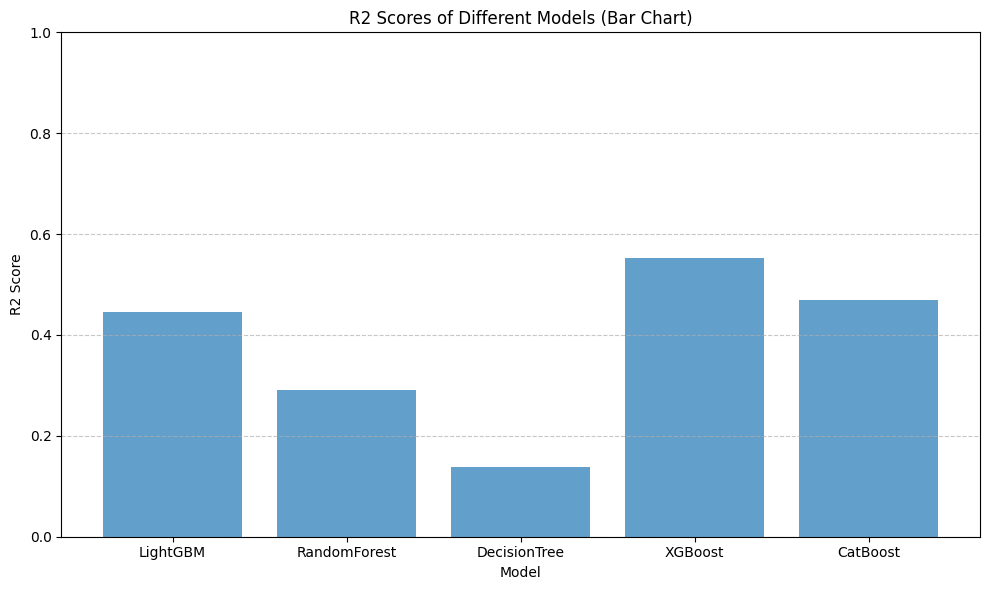

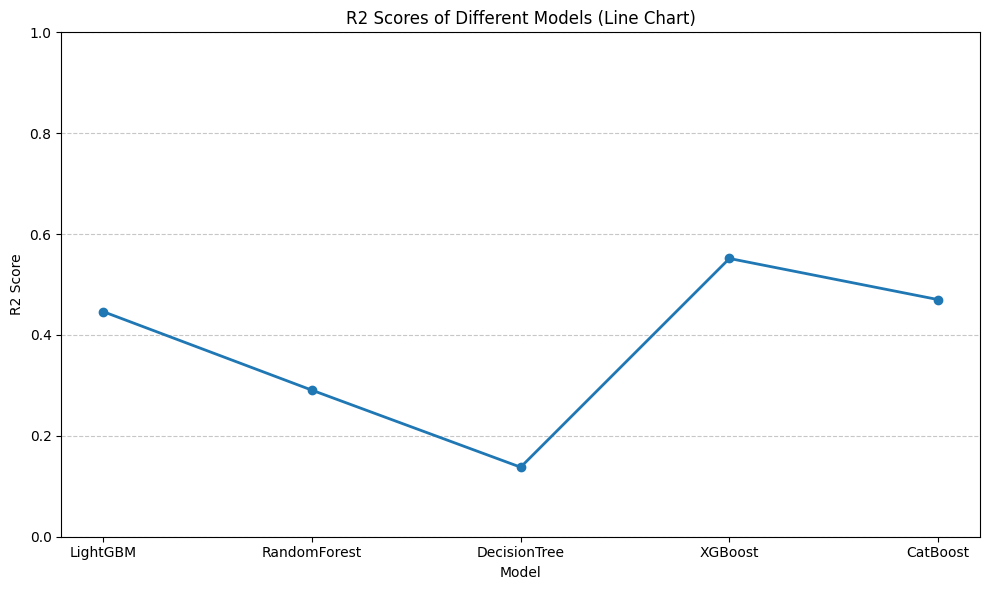

In [84]:
#Plot R2 Score
plot_metric(
    results,
    metric_key="R2",
    title="R2 Scores of Different Models",
    ylabel="R2 Score",
    ylim=(0, 1)
)


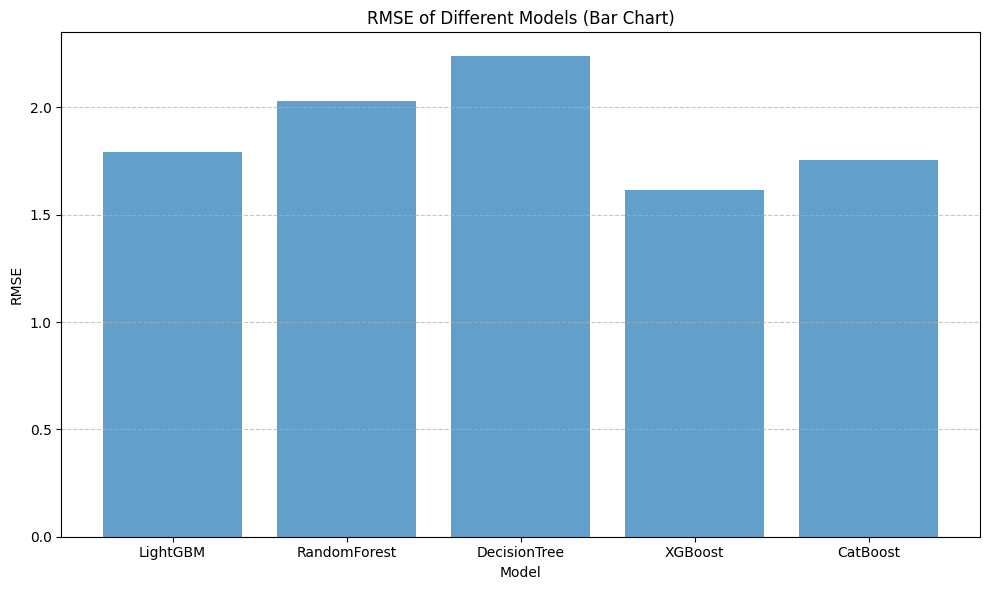

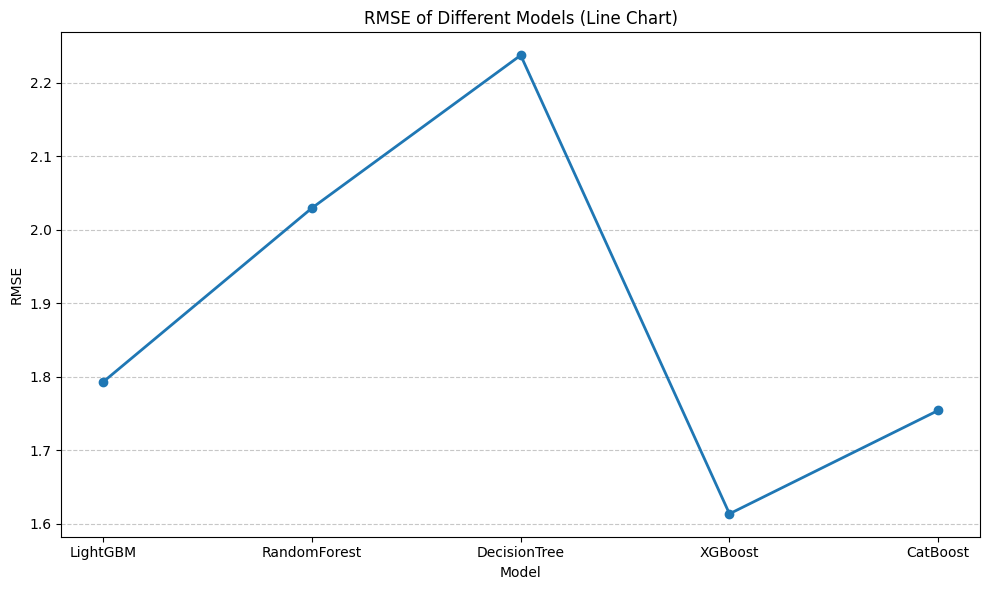

In [83]:
#Plot RMSE Score
plot_metric(
    results,
    metric_key="RMSE",
    title="RMSE of Different Models",
    ylabel="RMSE",
    ylim=None
)

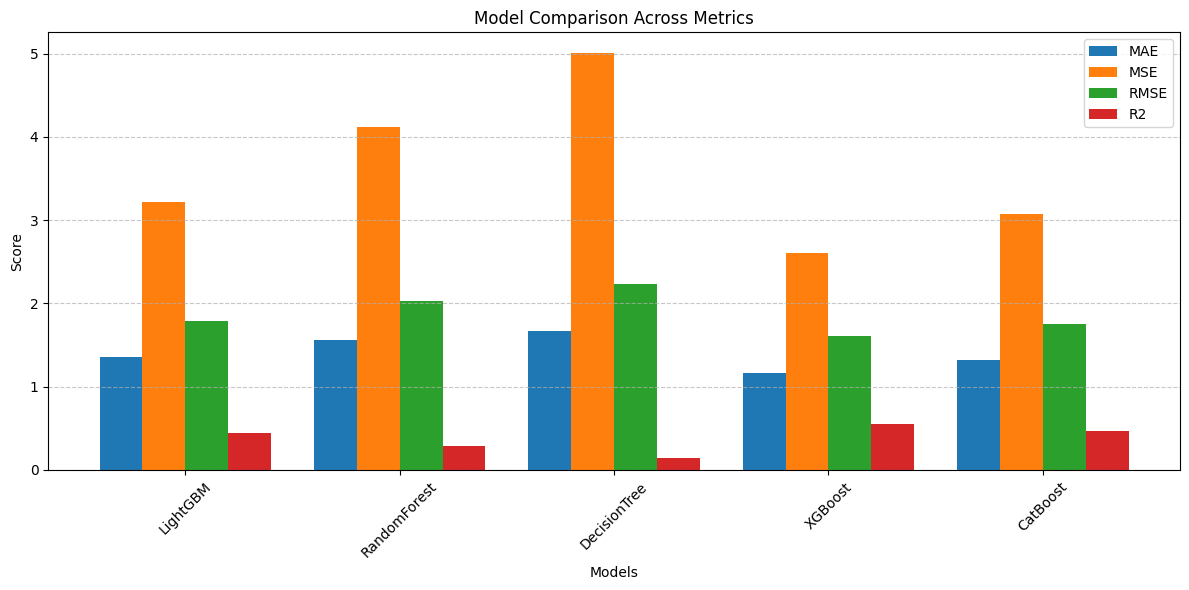

In [85]:


metrics = ['MAE', 'MSE', 'RMSE', 'R2']
model_names = [res['Model'] for res in results]

# lấy giá trị metric
metric_values = {
    metric.strip(): [res[metric] for res in results]
    for metric in metrics
}

x = np.arange(len(model_names))  # vị trí model
width = 0.2 

plt.figure(figsize=(12, 6))

for i, (metric, values) in enumerate(metric_values.items()):
    plt.bar(x + i * width, values, width, label=metric)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Comparison Across Metrics')
plt.xticks(x + width * (len(metrics) - 1) / 2, model_names, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



TEST DỰ ĐOÁN

In [91]:
from sentence_transformers import SentenceTransformer

# Import embed model
embed_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", device="cuda")

In [107]:
def build_feature_vector(
    title: str,
    desc: str,
    project_key: str,
    embed_model,
    scaler,
    le
):
    # Combine text
    text = (title or "") + " " + (desc or "")

    # ---- EMBEDDING ----
    emb = embed_model.encode(
        text,
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    # ---- EXTRA FEATURES ----
    word_count = len(text.split())
    char_count = len(text)

    extra = pd.DataFrame(
        [[word_count, char_count]],
        columns=["word_count", "char_count"]
    )
    extra_scaled = scaler.transform(extra)

    # ---- PROJECT KEY ----
    key_encoded = le.transform([project_key])[0]

    # ---- FINAL VECTOR ----
    X_input = np.hstack([
        emb.reshape(1, -1),     # (1, 384)
        extra_scaled,           # (1, 2)
        np.array([[key_encoded]])  # (1, 1)
    ])

    return X_input


In [ ]:
def predict_story_point_multi(
    models: dict,
    title: str,
    desc: str,
    project_key: str,
    embed_model,
    scaler,
    le
):
    """
    models = {
        "LightGBM": lgb_model,
        "RandomForest": rf_model,
        "XGBoost": xgb_model,
        "CatBoost": cat_model
    }
    """

    X_input = build_feature_vector(
        title, desc, project_key,
        embed_model, scaler, le
    )

    preds = {}
    for name, model in models.items():
        preds[name] = round(float(model.predict(X_input)[0]), 2)

    return preds


In [110]:
models_dict = {
    "LightGBM": lgb_model,
    "RandomForest": rf_model,
    "DecisionTree": dt_model,
    "XGBoost": xgb_model,
    "CatBoost": cat_model
}

In [120]:
# Danh sách test tiếng Việt
test_cases = [
    ("Lỗi đăng nhập", "Người dùng không thể đăng nhập bằng Google trên ứng dụng di động.", "JSW"),
    ("Thêm tooltip UI", "Thêm tooltip cho nút tạo task để người dùng hiểu rõ chức năng.", "TIDOC"),
    ("Tối ưu backend", "Refactor toàn bộ API, cải thiện tốc độ phản hồi cho hệ thống.", "MDL"),
    ("Sửa lỗi crash khi upload file", "Ứng dụng bị crash khi upload file trên trình duyệt Safari.", "MDL"),
    ("Thêm phân quyền mới", "Thêm quyền 'Supervisor' để xem báo cáo nhưng không được chỉnh sửa task.", "TIDOC"),
    ("Cải thiện tốc độ tìm kiếm", "Tối ưu query và thêm caching để kết quả tìm kiếm hiển thị nhanh hơn.", "JSW"),
    ("Fix lỗi hiển thị UI", "Icon menu bị lệch vị trí trên màn hình iPhone 12.", "JSW"),
    ("Thêm login bằng Facebook", "Người dùng có thể đăng nhập bằng tài khoản Facebook.", "JSW"),
    ("Phát triển dashboard thống kê", "Xây dựng dashboard hiển thị KPI dự án theo thời gian thực.", "TIDOC"),
    ("Sửa lỗi email không gửi", "Hệ thống không gửi email xác thực đối với domain Outlook.", "JSW")
]

print(" Kết quả dự đoán Story Point:")
rows = []

for title, desc, key in test_cases:
    preds = predict_story_point_multi(
        models_dict,
        title, desc, key,
        embed_model,
        scaler,
        le #Label Encoder
    )

    row = {
        "Project": key,
        "Title": title,
        "Description": desc
    }

    # Mỗi model → 1 cột
    for model_name, sp in preds.items():
        row[f"{model_name}"] = sp

    rows.append(row)

df_result = pd.DataFrame(rows)

df_result



 Kết quả dự đoán Story Point:


e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packag

,Project,Title,Description,LightGBM,RandomForest,DecisionTree,XGBoost,CatBoost
0,JSW,Lỗi đăng nhập,Người dùng không thể đăng nhập bằng Google trê...,3.42,3.16,4.52,3.17,2.83
1,TIDOC,Thêm tooltip UI,Thêm tooltip cho nút tạo task để người dùng hi...,3.04,2.98,2.83,3.24,3.60
2,MDL,Tối ưu backend,"Refactor toàn bộ API, cải thiện tốc độ phản hồ...",4.34,4.40,4.09,4.67,5.16
3,MDL,Sửa lỗi crash khi upload file,Ứng dụng bị crash khi upload file trên trình d...,3.23,2.96,4.52,3.36,3.49
4,TIDOC,Thêm phân quyền mới,Thêm quyền 'Supervisor' để xem báo cáo nhưng k...,1.48,2.73,4.15,1.36,1.56
5,JSW,Cải thiện tốc độ tìm kiếm,Tối ưu query và thêm caching để kết quả tìm ki...,4.72,3.95,3.39,5.62,5.19
6,JSW,Fix lỗi hiển thị UI,Icon menu bị lệch vị trí trên màn hình iPhone 12.,3.35,3.68,3.86,3.02,1.73
7,JSW,Thêm login bằng Facebook,Người dùng có thể đăng nhập bằng tài khoản Fac...,3.37,4.05,3.27,3.55,2.91
8,TIDOC,Phát triển dashboard thống kê,Xây dựng dashboard hiển thị KPI dự án theo thờ...,3.50,2.85,2.26,2.86,3.61
9,JSW,Sửa lỗi email không gửi,Hệ thống không gửi email xác thực đối với doma...,3.25,3.20,3.86,3.26,2.87


In [89]:
# Test cases song ngữ (theo cặp)
test_pairs = [
    (
        ("Lỗi đăng nhập", "Người dùng không thể đăng nhập bằng Google trên ứng dụng di động.", "JSW"),
        ("Login error", "Users cannot log in with Google on the mobile app.", "JSW")
    ),
    (
        ("Thêm tooltip UI", "Thêm tooltip cho nút tạo task để người dùng hiểu rõ chức năng.", "TIDOC"),
        ("Add UI tooltip", "Add tooltip for the create task button to help users understand its function.", "TIDOC")
    ),
    (
        ("Tối ưu backend", "Refactor toàn bộ API, cải thiện tốc độ phản hồi cho hệ thống.", "MDL"),
        ("Optimize backend", "Refactor all APIs to improve system response speed.", "MDL")
    ),
    (
        ("Sửa lỗi crash khi upload file", "Ứng dụng bị crash khi upload file trên trình duyệt Safari.", "MDL"),
        ("Fix crash on file upload", "The app crashes when uploading files on Safari browser.", "MDL")
    ),
    (
        ("Thêm phân quyền mới", "Thêm quyền 'Supervisor' để xem báo cáo nhưng không được chỉnh sửa task.", "TIDOC"),
        ("Add new permission", "Add 'Supervisor' role to view reports but not edit tasks.", "TIDOC")
    ),
    (
        ("Cải thiện tốc độ tìm kiếm", "Tối ưu query và thêm caching để kết quả tìm kiếm hiển thị nhanh hơn.", "JSW"),
        ("Improve search speed", "Optimize queries and add caching to speed up search results.", "JSW")
    ),
    (
        ("Fix lỗi hiển thị UI", "Icon menu bị lệch vị trí trên màn hình iPhone 12.", "JSW"),
        ("Fix UI display issue", "Menu icon is misaligned on iPhone 12 screen.", "JSW")
    ),
    (
        ("Thêm login bằng Facebook", "Người dùng có thể đăng nhập bằng tài khoản Facebook.", "JSW"),
        ("Add login with Facebook", "Users can log in using their Facebook accounts.", "JSW")
    ),
    (
        ("Phát triển dashboard thống kê", "Xây dựng dashboard hiển thị KPI dự án theo thời gian thực.", "TIDOC"),
        ("Develop statistics dashboard", "Build a dashboard to display project KPIs in real-time.", "TIDOC")
    ),
    (
        ("Sửa lỗi email không gửi", "Hệ thống không gửi email xác thực đối với domain Outlook.", "JSW"),
        ("Fix email sending issue", "The system fails to send verification emails for Outlook domain.", "JSW")
    )
]


In [124]:
rows = []

for (title_vn, desc_vn, key), (title_en, desc_en, _) in test_pairs:
    pred_vn = predict_story_point_multi(
        models_dict, title_vn, desc_vn, key,
        embed_model, scaler, le
    )

    pred_en = predict_story_point_multi(
        models_dict, title_en, desc_en, key,
        embed_model, scaler, le
    )

    for m in models_dict.keys():
        rows.append({
            "Project": key,
            "Model": m,
            "Title_vn": title_vn,
            "Title_en": title_en,
            "SP_VN": pred_vn[m],
            "SP_EN": pred_en[m],
            "Độ lệch": round(abs(pred_vn[m] - pred_en[m]), 2)
        })

df_long = pd.DataFrame(rows)
df_long


e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\KLTN\Data_mining\env1\Lib\site-packag

,Project,Model,Title_vn,Title_en,SP_VN,SP_EN,Độ lệch
0,JSW,LightGBM,Lỗi đăng nhập,Login error,3.42,2.62,0.80
1,JSW,RandomForest,Lỗi đăng nhập,Login error,3.16,3.10,0.06
2,JSW,DecisionTree,Lỗi đăng nhập,Login error,4.52,4.52,0.00
3,JSW,XGBoost,Lỗi đăng nhập,Login error,3.17,2.85,0.32
4,JSW,CatBoost,Lỗi đăng nhập,Login error,2.83,3.13,0.30
5,TIDOC,LightGBM,Thêm tooltip UI,Add UI tooltip,3.04,3.03,0.01
6,TIDOC,RandomForest,Thêm tooltip UI,Add UI tooltip,2.98,2.81,0.17
7,TIDOC,DecisionTree,Thêm tooltip UI,Add UI tooltip,2.83,1.76,1.07
8,TIDOC,XGBoost,Thêm tooltip UI,Add UI tooltip,3.24,2.78,0.46
9,TIDOC,CatBoost,Thêm tooltip UI,Add UI tooltip,3.60,3.19,0.41


In [116]:
import os
import joblib

BASE_DIR = "models/minil12"
PREFIX = "[MiniL12]"

models_dict = {
    "LightGBM": lgb_model,
    "RandomForest": rf_model,
    "DecisionTree": dt_model,
    "XGBoost": xgb_model,
    "CatBoost": cat_model
}

# Tạo thư mục gốc
os.makedirs(BASE_DIR, exist_ok=True)

# Lưu từng model vào folder riêng
for model_name, model in models_dict.items():
    model_dir = os.path.join(BASE_DIR, model_name)
    os.makedirs(model_dir, exist_ok=True)

    model_path = os.path.join(
        model_dir, f"{PREFIX}_{model_name}.pkl"
    )
    joblib.dump(model, model_path)
    print(f"Đã lưu: {model_path}")

# Lưu scaler (dùng chung)
shared_dir = os.path.join(BASE_DIR, "shared")
os.makedirs(shared_dir, exist_ok=True)

scaler_path = os.path.join(shared_dir, f"{PREFIX}_scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"Đã lưu: {scaler_path}")


Đã lưu: models/minil12\LightGBM\[MiniL12]_LightGBM.pkl
Đã lưu: models/minil12\RandomForest\[MiniL12]_RandomForest.pkl
Đã lưu: models/minil12\DecisionTree\[MiniL12]_DecisionTree.pkl
Đã lưu: models/minil12\XGBoost\[MiniL12]_XGBoost.pkl
Đã lưu: models/minil12\CatBoost\[MiniL12]_CatBoost.pkl
Đã lưu: models/minil12\shared\[MiniL12]_scaler.pkl
